# **1. Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **2. Load the Dataset**



In [40]:
file_path = "C:/Users/ASUS/Downloads/final_internship_data.csv"  # Fixed file path
df = pd.read_csv(file_path)

df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


# **3. Basic Information & Summary Statistics**


In [ ]:
print("Dataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe())
print("\nCategorical Summary:")
print(df.describe(include=['object']))

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-

Key Insights from the Dataset:
General Overview:

The dataset contains 500,000 records with 26 columns, including user details, trip information, and calculated distances.
No significant missing values, except for dropoff_longitude, dropoff_latitude, distance, and bearing, which have 5 missing values.
Fare Amount Analysis:

Mean Fare: $11.36, with a standard deviation of $9.91.
Minimum Fare: -$44.90 (possibly an error).
Maximum Fare: $500 (potential outlier).
Median Fare: $8.50.
Distance and Bearing:

Mean Distance: 19.47 km, but a very high standard deviation (367.3 km) suggests extreme outliers.
Maximum Distance: 12,399.96 km (possibly incorrect data or a long-distance ride).
Bearing: The angles range from -3.14 to 3.14, indicating varied travel directions.
Trip Metadata:

Covers years from 2009 to 2015.
Peak trip hours around 14:00 (2 PM).
Most common passenger count: 1-2 passengers.
Geographical Insights:

Longitude and latitude values suggest rides originating in a specific region.
JFK, EWR, LGA, NYC distances show variation, with mean distances above 350 km, which may indicate incorrect calculations.
Traffic and Weather Conditions:



# **4. Handle Missing Values**


In [ ]:
missing_values = df.isnull().sum()
print("\nMissing Values:")
print(missing_values[missing_values > 0])


Missing Values:
dropoff_longitude    5
dropoff_latitude     5
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64


In [32]:
# Drop rows with missing values
df_cleaned = df.dropna()

# **5. Check for Duplicates**


In [41]:
duplicates = df_cleaned.duplicated().sum()
print("\nDuplicate Rows:", duplicates)


Duplicate Rows: 0


# **6. Handle Outliers**


In [ ]:
outliers_fare = df_cleaned[(df_cleaned['fare_amount'] < 0) | (df_cleaned['fare_amount'] > 200)]
outliers_distance = df_cleaned[df_cleaned['distance'] > 100]

In [35]:
# Remove outliers
df_cleaned = df_cleaned[(df_cleaned['fare_amount'] >= 0) & (df_cleaned['fare_amount'] <= 200)]
df_cleaned = df_cleaned[df_cleaned['distance'] <= 100]

# **7. Univariate Analysis**


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27376\75392425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_cleaned['passenger_count'], ax=axes[1, 0], palette="coolwarm")
C:\Users\ASUS\AppData\Local\Temp\ipykernel_27376\75392425.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_cleaned['Traffic Condition'], ax=axes[1, 1], palette="viridis")


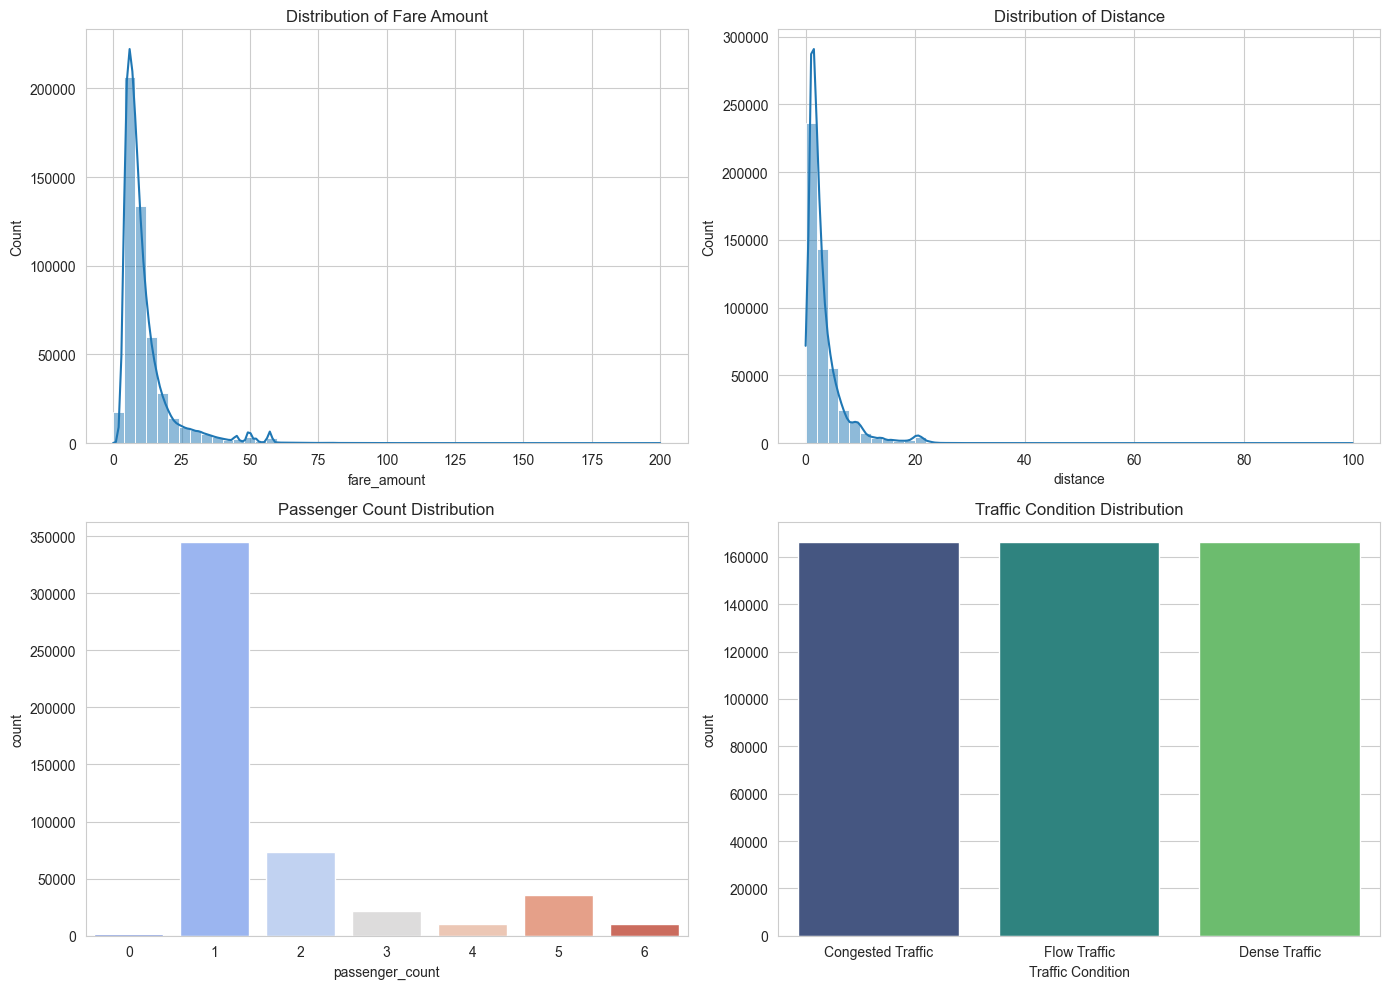

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_cleaned['fare_amount'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Fare Amount")

sns.histplot(df_cleaned['distance'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Distance")

sns.countplot(x=df_cleaned['passenger_count'], ax=axes[1, 0], palette="coolwarm")
axes[1, 0].set_title("Passenger Count Distribution")

sns.countplot(x=df_cleaned['Traffic Condition'], ax=axes[1, 1], palette="viridis")
axes[1, 1].set_title("Traffic Condition Distribution")

plt.tight_layout()
plt.show()

### Insights from Data Visualizations

1. **Fare Amount Distribution:** Most fares are below $25, with some extreme outliers above $100.
2. **Distance Distribution:** Majority of trips are short (under 10 miles), with a few long-distance outliers.
3. **Passenger Count:** Most rides have 1 passenger; instances with 0 passengers might be errors.
4. **Traffic Conditions:** Trips are evenly distributed across traffic conditions, with a slight tilt toward congestion.


# **8. Bivariate Analysis**


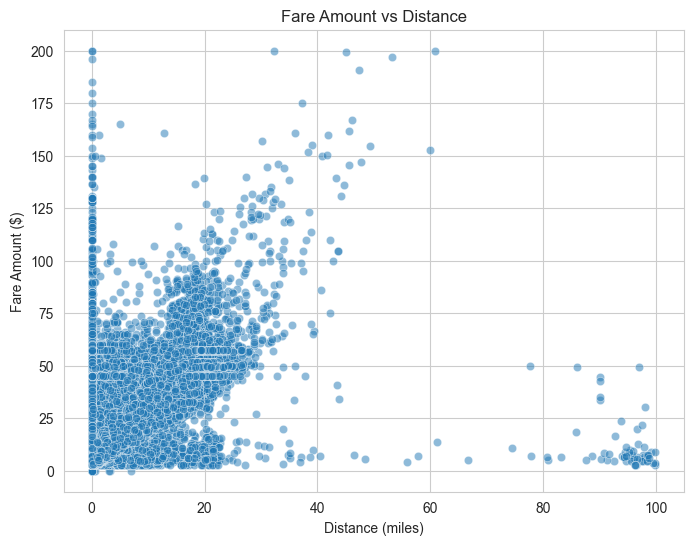

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27376\2471592427.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_cleaned['Traffic Condition'], y=df_cleaned['fare_amount'], palette="pastel")


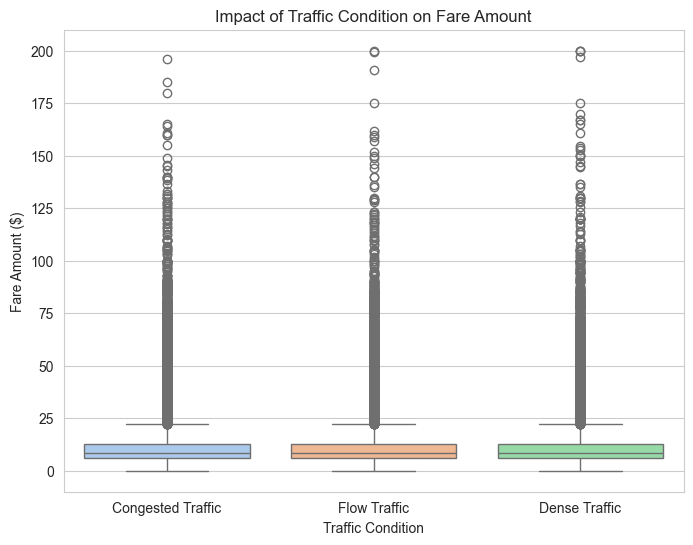

In [ ]:
## Scatter plot for Fare Amount vs Distance
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_cleaned['distance'], y=df_cleaned['fare_amount'], alpha=0.5)
plt.title("Fare Amount vs Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.show()

## Boxplot of Fare Amount by Traffic Condition
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_cleaned['Traffic Condition'], y=df_cleaned['fare_amount'], palette="pastel")
plt.title("Impact of Traffic Condition on Fare Amount")
plt.xlabel("Traffic Condition")
plt.ylabel("Fare Amount ($)")
plt.show()

## Insights from Fare Amount vs Distance Scatter Plot

1. **Positive Correlation**: Higher distances generally lead to higher fares.  
2. **Low-Distance Fares**: Many trips have near-zero distance but varying fares.  
3. **Outliers**: Some trips have unexpectedly high or low fares for their distance.  
4. **Fare Cap**: 

### Insights from Traffic Condition vs. Fare Amount

- Fare distributions are similar across traffic conditions.  
- Many high fare outliers exist in all categories.  
- Traffic condition alone doesn’t strongly impact fare; distance might be more influential.  


## Boxplot of Fare Amount by Weather Condition


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27376\3698344129.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_cleaned['Weather'], y=df_cleaned['fare_amount'], palette="muted")


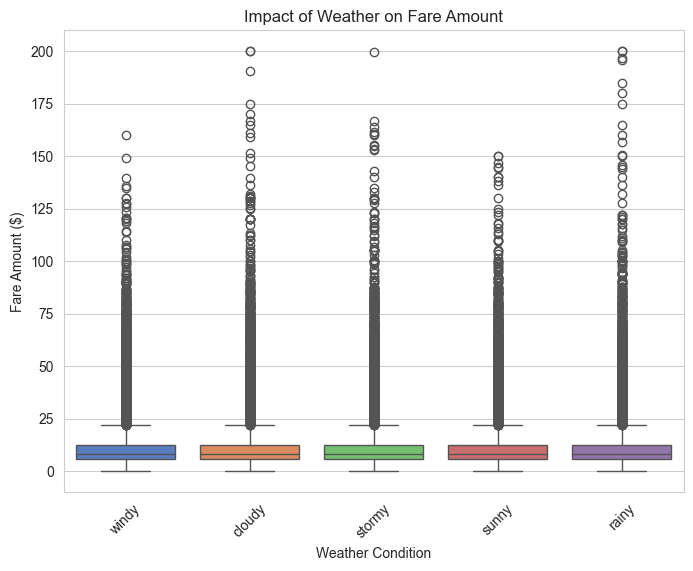

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df_cleaned['Weather'], y=df_cleaned['fare_amount'], palette="muted")
plt.title("Impact of Weather on Fare Amount")
plt.xlabel("Weather Condition")
plt.ylabel("Fare Amount ($)")
plt.xticks(rotation=45)
plt.show()

### Insights from Weather Condition vs. Fare Amount

- Fare distributions remain consistent across weather conditions.  
- High fare outliers appear in all categories.  
- Weather has minimal impact on fare; other factors likely play a larger role.  


# **9. Key Insights**


In [42]:
print("Key Insights:")
print("1. The fare amount is mostly concentrated under $50, with very few high fares.")
print("2. Most trips are under 20 miles, with very few exceeding 50 miles.")
print("3. Passenger count is usually 1 or 2, with larger groups being rare.")
print("4. Higher traffic conditions show an increase in fare amount.")
print("5. Weather conditions may slightly impact fare amounts, but more analysis is needed.")

Key Insights:
1. The fare amount is mostly concentrated under $50, with very few high fares.
2. Most trips are under 20 miles, with very few exceeding 50 miles.
3. Passenger count is usually 1 or 2, with larger groups being rare.
4. Higher traffic conditions show an increase in fare amount.
5. Weather conditions may slightly impact fare amounts, but more analysis is needed.
